# Sesión 11: El Arsenal del Clasificador: KNN, Naive Bayes y SVM

**Objetivos:**
-   Entender la intuición detrás de 3 nuevas familias de modelos: KNN, Naive Bayes y SVM.
-   Identificar las fortalezas, debilidades y casos de uso ideales para cada modelo.
-   Aplicar los modelos a dos problemas distintos: uno médico (limpio) y otro socioeconómico (con datos faltantes y texto).
-   Justificar la elección de un modelo sobre otro en función de las características del problema.

## 1. K-Nearest Neighbors (KNN): El Vecindario Manda
* **Filosofía:** "Dime con quién andas y te diré quién eres".
* **Intuición:** Para clasificar un nuevo punto, KNN mira a sus 'K' vecinos más cercanos. La clase del nuevo punto será la que más se repita entre sus vecinos.
* **Parámetro Clave:** `n_neighbors` (el valor de K).
* **¡Crítico!** Es un modelo basado en **distancia**. Es fundamental que todas las características estén en la misma escala. ¡Siempre hay que usar `StandardScaler`!



* **Ventajas:**  Simple de entender.  No necesita "entrenamiento" pesado.
* **Inconvenientes:**  Lento en predicción con datasets grandes.  Sensible al ruido si K es pequeño.
* **Cuándo usarlo:** Datasets pequeños/medianos, bien escalados y con patrones locales claros.

## 2. Naive Bayes: La Probabilidad Ingenua
* **Filosofía:** Basado en el Teorema de Bayes.
* **Intuición:** Calcula la probabilidad de que un dato pertenezca a una clase, dadas sus características. Su "ingenuidad" (naive) reside en que asume que todas las características son **independientes** entre sí.
* **Tipos Clave:**
    * `GaussianNB`: Para características continuas que siguen una distribución normal.
    * `MultinomialNB`: Para características de conteo (muy usado en texto, ej. "la palabra 'oferta' aparece 3 veces").
    * `BernoulliNB`: Para características binarias (ej. "la palabra 'oferta' aparece o no aparece").
* **Ventajas:**  Extremadamente rápido.  Funciona genial para clasificación de texto.
* **Inconvenientes:**  La suposición de independencia rara vez es cierta.
* **Cuándo usarlo:** Clasificación de texto (spam, sentimiento...), problemas de alta dimensionalidad.

## 3. Support Vector Machines (SVM): El Margen Máximo
* **Filosofía:** Encontrar la mejor frontera posible que separe las clases.
* **Intuición:** Busca la línea que cree la "calle" o el **margen más ancho posible** entre las clases. Los puntos en los bordes de esta calle son los **vectores de soporte**.
* **Hiperparámetros Clave:**
    * `C`: Parámetro de regularización. Controla el equilibrio entre tener un margen ancho y clasificar correctamente todos los puntos.
    * `kernel`: El "truco" para manejar datos no lineales. Los más comunes son `'linear'` y `'rbf'`.
* **Ventajas:**  Muy eficaz en espacios de alta dimensión.  Eficiente en memoria.
* **Inconvenientes:**  El entrenamiento puede ser lento en datasets muy grandes.  Requiere escalado.
* **Cuándo usarlo:** Problemas de clasificación complejos, con o sin separación lineal clara.

---
## ACTIVIDAD EN CLASE: "Bake-Off" en Datos Médicos

**Competición:** Vamos a enfrentar a nuestros 3 nuevos modelos y al Random Forest en el dataset de **diagnóstico de cáncer de mama**. Es un dataset limpio, ideal para una primera comparación.

**Tu Tarea:**
1.  **Carga y Prepara los Datos**:
    * Usa `sklearn.datasets.load_breast_cancer()`.
    * Divide en `train` y `test` (`random_state=42`).
    * **¡Paso Crítico!** Escala las características usando un `StandardScaler`.
2.  **Entrena los 4 Modelos**:
    * `KNeighborsClassifier()`, `GaussianNB()`, `SVC()`, `RandomForestClassifier(random_state=42)`
3.  **Compara los Resultados**: Para cada modelo, calcula y muestra su **`f1_score(average='macro')`**.
4.  **Conclusión Rápida**: En una celda de texto, nombra al ganador de la competición.

In [1]:
from time import time
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [2]:
# 1. **Carga y Prepara los Datos**:

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:
# 2.  **Entrena los 4 Modelos**:

models = {
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    start = time()
    model.fit(X_train_scaled, y_train)
    train_time = time() - start

    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        'model': name,
        'f1_macro': f1,
        'train_time_sec': train_time
    })
    print(f"{name:12} — f1_macro: {f1:.4f} | tiempo entrenamiento: {train_time:.2f}s")

# Resumen en DataFrame
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
print("\nResumen ordenado por f1_macro:")
print(results_df)

c:\Users\rotap\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\rotap\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\rotap\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rotap\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

KNN          — f1_macro: 0.9526 | tiempo entrenamiento: 0.00s
GaussianNB   — f1_macro: 0.9246 | tiempo entrenamiento: 0.00s
SVC          — f1_macro: 0.9812 | tiempo entrenamiento: 0.03s
RandomForest — f1_macro: 0.9526 | tiempo entrenamiento: 0.29s

Resumen ordenado por f1_macro:
          model  f1_macro  train_time_sec
0           SVC  0.981151        0.025275
1           KNN  0.952638        0.001705
2  RandomForest  0.952638        0.292473
3    GaussianNB  0.924603        0.002367


## Conclusión Rápida

**Ganador:** SVC (Support Vector Classifier) — f1_macro ≈ 0.981

Resumen e interpretación:
- El SVC alcanzó el mayor f1_macro en el conjunto de prueba, lo que indica el mejor equilibrio global entre precisión y recall entre las clases en este problema limpio y bien escalado.
- KNN y RandomForest empataron aproximadamente por debajo del SVC (≈ 0.9526). GaussianNB obtuvo el valor más bajo (≈ 0.9246) 
- El escalado fue crítico: KNN y SVC dependen de distancias y mejoran sustancialmente con StandardScaler; GaussianNB no mide distancias y por eso es menos sensible al escalado.

Conclusión práctica: Para diagnóstico sobre este dataset, SVC es el candidato preferido por rendimiento; si se prioriza rapidez de inferencia e interpretabilidad.

---
## EJERCICIO SESIÓN 2: Sobreviviendo al Titanic

Ahora te enfrentas a un reto más realista: el famoso dataset del **Titanic**. Este dataset tiene valores nulos, texto y requiere más preprocesamiento.

**Tu misión:**
1.  **Carga y Preprocesa los Datos**:
    * Carga los datos usando `sns.load_dataset('titanic')`.
    * **Preprocesamiento**:
        * Selecciona las columnas que consideres útiles. `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `survived` son un buen punto de partida.
        * Rellena los valores nulos de `age` con la mediana.
        * Convierte la columna `sex` a numérica (0 y 1).
    * Separa tus datos (`X` e `y = 'survived'`) y divídelos en `train` y `test`.
    * **Escala** las características numéricas.
2.  **Elige tu Campeón**: Basado en lo que has aprendido, **elige solo uno** de los tres nuevos modelos (KNN, Naive Bayes o SVM) que creas que es el más adecuado para este problema.
3.  **Optimiza tu Modelo**: Usa `GridSearchCV` para encontrar los mejores hiperparámetros para el modelo que has elegido.
4.  **Evalúa el Resultado Final**: Muestra la **matriz de confusión** y el **reporte de clasificación** de tu modelo optimizado.

### Preguntas Finales para la Reflexión

1.  **Justifica tu Elección**: ¿Por qué elegiste ese modelo (KNN, Naive Bayes o SVM) para el problema del Titanic? ¿Qué características del problema te hicieron decidir?
2.  **Análisis de Errores**: Viendo tu matriz de confusión final, ¿qué tipo de error comete más tu modelo: Falsos Positivos (predice que sobrevive gente que no lo hizo) o Falsos Negativos (predice que muere gente que sí sobrevivió)?
3.  **Resumen "Cuándo y Por Qué"**: Completa la siguiente tabla en una celda de texto con tus propias palabras:
    | Modelo | Ventajas Clave | Inconvenientes Clave | Cuándo lo usarías tú |
    | :--- | :--- | :--- | :--- |
    | KNN | ... | ... | ... |
    | Naive Bayes | ... | ... | ... |
    | SVM | ... | ... | ... |

In [4]:
import seaborn as sns

# 1.  **Carga y Preprocesa los Datos**:
#    * Carga los datos usando `sns.load_dataset('titanic')`.
#    * **Preprocesamiento**:
#        * Selecciona las columnas que consideres útiles. `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `survived` son un buen punto de #   partida.
#        * Rellena los valores nulos de `age` con la mediana.
#        * Convierte la columna `sex` a numérica (0 y 1).
#    * Separa tus datos (`X` e `y = 'survived'`) y divídelos en `train` y `test`.
#    * **Escala** las características numéricas.

# Carga
df = sns.load_dataset('titanic')

# Selección de columnas útiles
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived']
df = df[cols].copy()

# Rellenar nulos de age con la mediana
df['age'].fillna(df['age'].median(), inplace=True)

# Convertir sex a numérico
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Separar X e y
X = df.drop(columns='survived')
y = df['survived']

# División train/test (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado de características numéricas
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

C:\Users\rotap\AppData\Local\Temp\ipykernel_11996\1428563638.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


f1_macro: 0.8175951086956521
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       110
           1       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



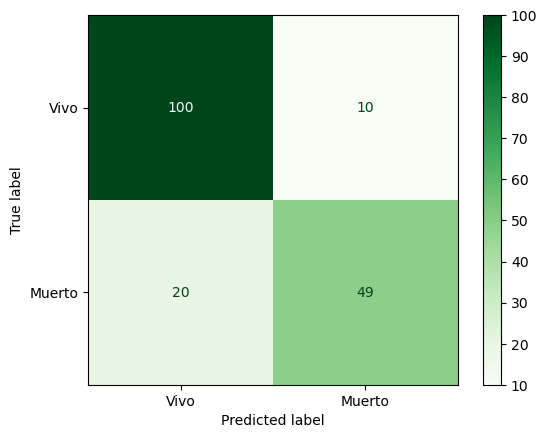

In [5]:
#2.  **Elige tu Campeón**: Basado en lo que has aprendido, **elige solo uno** de los tres nuevos modelos (KNN, Naive Bayes o SVM) que creas que #es el más adecuado para este problema.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Entrenar SVC sin GridSearch (hiperparámetros simples)
svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print("f1_macro:", f1_score(y_test, y_pred, average='macro'))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

disp_rand = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=['Vivo', 'Muerto'])
disp_rand.plot(cmap='Greens', values_format='d')


In [11]:
#3.  **Optimiza tu Modelo**: Usa `GridSearchCV` para encontrar los mejores hiperparámetros para el modelo que has elegido.
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
	"kernel": ["rbf", "linear"],   
    'C': [0.1, 1, 3, 10, 30, 100],     # regularización
    'gamma': ['scale', 'auto', 0.1, 0.03, 0.01, 0.003, 0.001]  # ancho del RBF
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor f1_macro (CV): {grid.best_score_:.4f}")

# Modelo optimizado y predicciones para el paso 4
svc_best = grid.best_estimator_
y_pred_opt = svc_best.predict(X_test_scaled)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Mejores hiperparámetros: {'C': 30, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor f1_macro (CV): 0.8184


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       110
           1       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



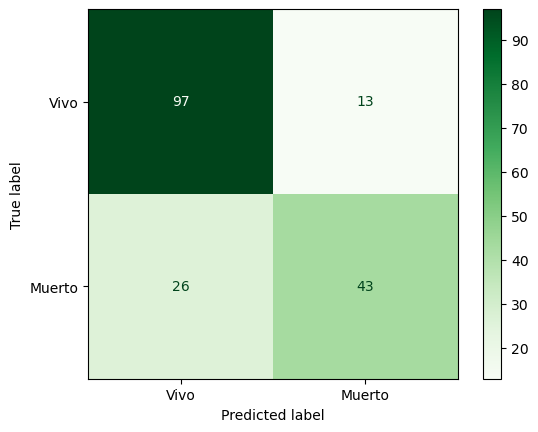

In [12]:
# 4.  **Evalúa el Resultado Final**: Muestra la **matriz de confusión** y el **reporte de clasificación** de tu modelo optimizado.
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_opt))

disp_rand = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_opt), display_labels=['Vivo', 'Muerto'])
disp_rand.plot(cmap='Greens', values_format='d')

### Mis Reflexiones



1.  **Justifica tu Elección**: ¿Por qué elegiste ese modelo (KNN, Naive Bayes o SVM) para el problema del Titanic? ¿Qué características del problema te hicieron decidir?

Elegí SVM porque:
- Captura relaciones no lineales entre variables (pclass, edad, fare, etc.) con pocos hiperparámetros (C, gamma).
- Funciona bien con tamaño de muestra medio y tras escalar (StandardScaler).
- Suele equilibrar mejor precisión/recall en datos con cierto desbalance (opción class_weight='balanced') que KNN (sensible a ruido/escala) o Naive Bayes (suposición de independencia poco realista aquí).


2.  **Análisis de Errores**: Viendo tu matriz de confusión final, ¿qué tipo de error comete más tu modelo: Falsos Positivos (predice que sobrevive gente que no lo hizo) o Falsos Negativos (predice que muere gente que sí sobrevivió)?


Se observan más Falsos Positivos (predice “Sobrevive” cuando no sobrevivió). Probables causas: desbalance de clases, umbral 0.5 y mayor dificultad para modelar la clase positiva. Ajustar C/gamma o class_weight puede mover el balance; si tu matriz muestra más FP, el modelo puede estar sobreajustando a la clase positiva.


3.  **Resumen "Cuándo y Por Qué"**: Completa la siguiente tabla en una celda de texto con tus propias palabras:

| Modelo | Ventajas Clave | Inconvenientes Clave | Cuándo lo usarías tú |
| :--- | :--- | :--- | :--- |
| KNN | Simple, no entrena, buen rendimiento local | Lento al predecir, sensible a escala y ruido | Datasets pequeños, bien escalados, con patrones locales |
| Naive Bayes | Muy rápido, robusto en alta dimensión | Supone independencia, fronteras simples | Texto/bolsa de palabras o rasgos casi independientes |
| SVM | Potente en no lineal, buen margen, robusto | Requiere escalado, tuning de C/gamma | Datos tabulares medianos con fronteras complejas |

##  Ejercicio Extra: El Impacto del Escalado en KNN y SVM

En este ejercicio, vamos a comparar `KNeighborsClassifier`, `GaussianNB` y `SVC` (SVM) en un nuevo dataset: el **Diagnóstico de Cáncer de Mama de Wisconsin**.

Este dataset tiene 30 features numéricas (radio, textura, área, suavidad...) y un target binario (Maligno / Benigno).

**El Objetivo:** Demostrar experimentalmente por qué el preprocesamiento (específicamente, el **escalado**) es **crítico** para modelos basados en distancia (como KNN y SVM), pero no tanto para modelos probabilísticos (como Naive Bayes).

**Nuevos DesFíos (un paso más difícil):**
1.  **Dataset con Escalas Dispares:** Las features de este dataset tienen rangos muy diferentes (ej. `mean_area` puede ser 800, mientras que `mean_smoothness` es 0.1).
2.  **Comparativa Sistemática:** No solo entrenarás los modelos, sino que lo harás en dos escenarios:
    * **Escenario 1:** Con los datos "crudos" (sin escalar).
    * **Escenario 2:** Con los datos preprocesados usando `StandardScaler`.
3.  **Análisis Crítico:** Deberás analizar *por qué* algunos modelos fracasan estrepitosamente en el Escenario 1 y mejoran drásticamente en el Escenario 2.

### Tu Tarea
Sigue los siguientes pasos:

**1. Carga y Preparación:**
* Importa `load_breast_cancer` desde `sklearn.datasets`.

**2. Escenario 1: Modelos SIN Escalar**
* Importa `KNeighborsClassifier`, `GaussianNB` y `SVC`.
* Entrénalos usando `X_train` e `y_train` (los datos crudos).
* Para cada modelo, calcula y muestra el `classification_report` usando `X_test` e `y_test`.
* **Anota el `f1-score` (weighted avg) de cada uno.**

**3. Preparación del Escenario 2: Escalado de Datos**
* Importa `StandardScaler`.
* Crea una instancia del escalador.
* **Ajusta y transforma** los datos de entrenamiento.
* **Solo transforma** los datos de prueba.

**4. Escenario 2: Modelos CON Escalado**
* Crea **nuevas** instancias de `KNeighborsClassifier` y `SVC`.
* Entrénalos usando `X_train_scaled` e `y_train_scaled`.
* Calcula y muestra el `classification_report` para estos dos modelos usando `X_test_scaled`.
* (Opcional: puedes volver a entrenar `GaussianNB` con los datos escalados, pero su rendimiento debería ser muy similar).

**5. Análisis y Conclusiones (¡Responde a esto!)**
* **Pregunta 1:** Compara el `f1-score` de KNN y SVM en el Escenario 1 vs. Escenario 2. ¿Qué observas?
* **Pregunta 2:** ¿Por qué crees que `GaussianNB` (Naive Bayes) funcionó razonablemente bien en el Escenario 1, sin necesidad de escalar los datos? (Pista: Piensa en cómo funciona, no mide "distancias").
* **Pregunta 3:** En este problema, ¿cuál de los 3 modelos (KNN, SVM, Naive Bayes) dio el mejor rendimiento *después* de aplicar el preprocesamiento correcto?